In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import jit, njit, prange
@njit
def compute_c_records(x, c):
    records = [x[0]]
    occurrence_times = [0]
    for i in range(1,len(x)):
        if x[i] > records[-1] - c:
            records.append(x[i])
            occurrence_times.append(i)
    return np.array(records), np.array(occurrence_times)

In [ ]:
catalog = pd.read_csv('japanese-cat.csv', sep=r"\s+", parse_dates=["Origin_Time(UT)"])
magnitudes = catalog['JMA_Magnitude(Mj)'].values
times = catalog['Origin_Time(UT)'].values

In [97]:
m_thresholds = np.linspace(0, magnitudes[magnitudes>0].min(), 100)
window_sizes = 10000
stride = 100
c_values = np.linspace(0, 4, 31)
num_records = []
for c in c_values:
    for m_th in m_thresholds:
        for start in range(0, len(magnitudes) - window_sizes, stride):
            window_magnitudes = magnitudes[start:start + window_sizes]
            window_times = times[start:start + window_sizes]
            transformed_magnitudes = window_magnitudes - m_th
            transformed_magnitudes = transformed_magnitudes[transformed_magnitudes > 0]
            transformed_magnitudes /= transformed_magnitudes.mean()
            records, occurrence_times = compute_c_records(transformed_magnitudes, c)
            num_records.append([c, m_th, start, len(records), window_magnitudes.mean(), records.mean(), records.var()])
num_records = pd.DataFrame(num_records, columns=['c', 'm_threshold', 'start_index', 'num_records', 'mean_magnitude', 'mean_record', 'var_record'])

In [98]:
num_records_avg = num_records.groupby(['c', 'm_threshold']).mean().reset_index().drop(columns=['start_index'])

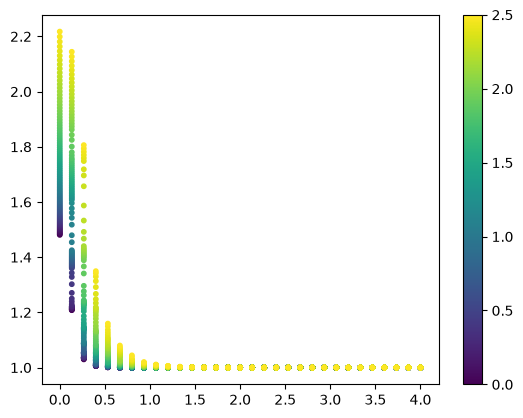

In [99]:
plt.scatter(num_records_avg['c'], num_records_avg['mean_record'], c=num_records_avg['m_threshold'], cmap='viridis', s=10)
plt.colorbar()
plt.show()